In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

current_dir = os.getcwd()
sys.path.append(os.path.dirname(current_dir))
sys.path.append(os.path.dirname(os.path.dirname(current_dir)))
from read_data_package.utils import *
from MYCRT_package.utils import *
from config import *

import warnings
warnings.filterwarnings("ignore")


## Compare the distributions of data X and Z

In [2]:
p = 200
data = data_load('Unnamed: 0','BRCA1P1','BRCA1',p)
z, zE, zU = data['z'], data['zE'], data['zU']
X, XE, XU = data['X'], data['XE'], data['XU']
z_name = data['z_name']
Uname = ['Basal','Her2','LumA','LumB','Normal-like']

In [3]:
lam_betahat = '100'
coef_in , lam_in = fit_lasso_model(z, X, lam_betahat)
coef_E , lam_E = fit_lasso_model(zE, XE, lam_betahat)
coef_U, lam_U = [], []
for zu, Xu in zip(zU, XU):
    coef_u , lam_u = fit_lasso_model(zu, Xu, lam_betahat)
    coef_U.append(coef_u)
    lam_U.append(lam_u)

In [4]:
unique_indices = np.argsort(-np.abs(coef_in))[:20]
coef_df = pd.DataFrame({'In': coef_in[unique_indices], 'E': coef_E[unique_indices]})
for i, coef_u in enumerate(coef_U):
    coef_df[f'U{i+1}']= coef_u[unique_indices]
coef_df.index = z_name[unique_indices]
unique_indices

array([ 69,  65, 151, 105, 140, 161, 167, 131,  37, 168,   2,  14,  31,
       104, 150,  67,   0, 138, 195, 178], dtype=int64)

In [5]:
Xz_data = (
    [{"Index": z_name[idx], "Source": "Internal", "Value": coef_in[idx]} for idx in unique_indices] +
    [{"Index": z_name[idx], "Source": "External", "Value": coef_E[idx]} for idx in unique_indices] 
    +[{"Index": z_name[idx], "Source": Uname[i], "Value": coef_U[i][idx]} 
     for i in range(len(coef_U)) for idx in unique_indices]
)
df = pd.DataFrame(Xz_data)

In [6]:
all_genes = df['Index'].unique()
sort_values = (df[df['Source'] == 'In'].groupby('Index')['Value'].mean().reindex(all_genes).fillna(0))
gene_order = sort_values.sort_values(ascending=False).index
df_sorted = df.set_index('Index').loc[gene_order].reset_index()

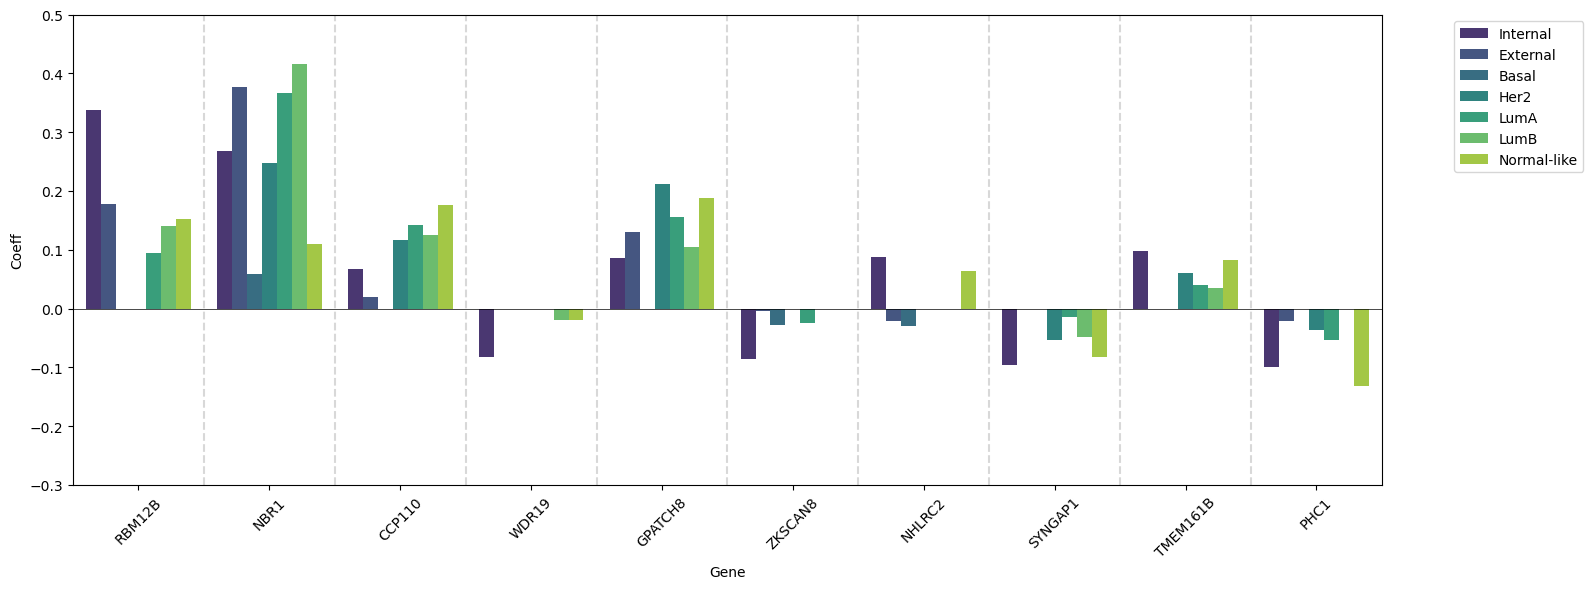

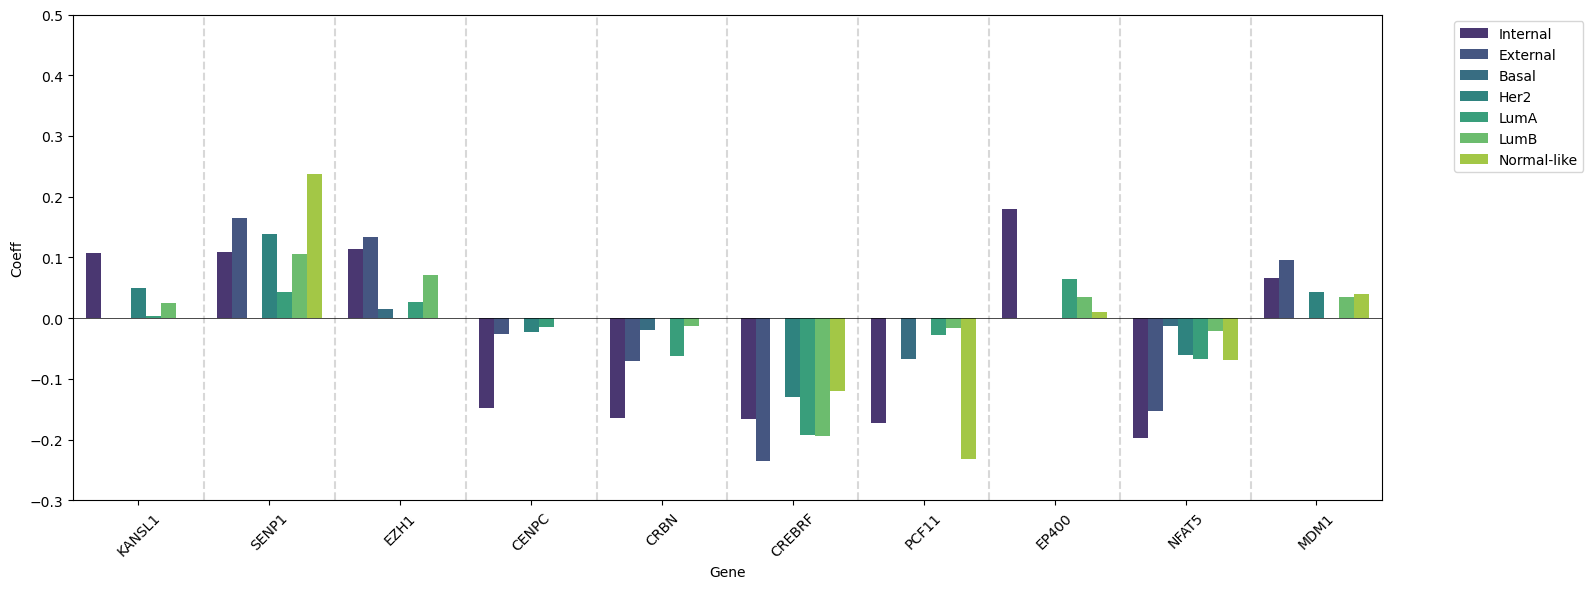

In [7]:
genes_per_plot = 10  
n_plots = (len(all_genes) + genes_per_plot - 1) // genes_per_plot

all_sources = df['Source'].unique()
output_dir = os.path.join('.', 'output', 'X-zCoeff')
os.makedirs(output_dir, exist_ok=True)
for i in range(n_plots):
    start_idx = i * genes_per_plot
    end_idx = (i + 1) * genes_per_plot
    genes_subset = gene_order[start_idx:end_idx]
    
    df_subset = df_sorted[df_sorted['Index'].isin(genes_subset)]
    
    full_index = pd.MultiIndex.from_product(
        [genes_subset, all_sources],
        names=['Index', 'Source']
    )
    df_subset = df_subset.set_index(['Index', 'Source']).reindex(full_index).reset_index()
    
    plt.figure(figsize=(16, 6))
    ax = sns.barplot(x="Index",y="Value",hue="Source",data=df_subset,palette="viridis",dodge=True,order=genes_subset)
    
    for j in range(len(genes_subset)-1):
        ax.axvline(j+0.5, color='gray', linestyle='--', alpha=0.3)
    
    plt.xticks(rotation=45)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, all_sources, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    y_min = min(-0.3, df_subset['Value'].min() * 1.1)
    y_max = max(0.5, df_subset['Value'].max() * 1.1)
    plt.ylim(y_min, y_max)
    plt.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel("Gene")
    ax.set_ylabel("Coeff")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'X-zCoeff{i}.pdf') , bbox_inches='tight', dpi=300)

## Compare the distributions of data Y and Z 

In [8]:
p = 200
call_name = 'Unnamed: 0'
Y_name = 'BRCA1P1'
X_name = 'BRCA1'
YXz, YXzE, _ = read_data(call_name, p)
Y, YE = YXz[Y_name].values, YXzE[Y_name].values
z, zE = YXz.drop(columns=[call_name, Y_name, X_name]).values, YXzE.drop(columns=[call_name, Y_name, X_name]).values
z_name = list(YXz.columns)
z_name.remove(call_name)
z_name.remove(Y_name)
z_name.remove(X_name)

In [9]:
lam_betahat = '100'
coef_in , lam_in = fit_lasso_model(z, Y, lam_betahat)
coef_E , lam_E = fit_lasso_model(zE, YE, lam_betahat)

In [10]:
unique_indices = np.argsort(-np.abs(coef_in))[:20]
coef_df = pd.DataFrame({'In': coef_in[unique_indices], 'E': coef_E[unique_indices]})

In [11]:
z_data = (
    [{"Index": z_name[idx], "Source": "Internal", "Value": coef_in[idx]} for idx in unique_indices] +
    [{"Index": z_name[idx], "Source": "External", "Value": coef_E[idx]} for idx in unique_indices]
)
df = pd.DataFrame(z_data)

In [12]:
all_genes = df['Index'].unique()
sort_values = (df[df['Source'] == 'In'].groupby('Index')['Value'].mean().reindex(all_genes).fillna(0))
gene_order = sort_values.sort_values(ascending=False).index
df_sorted = df.set_index('Index').loc[gene_order].reset_index()

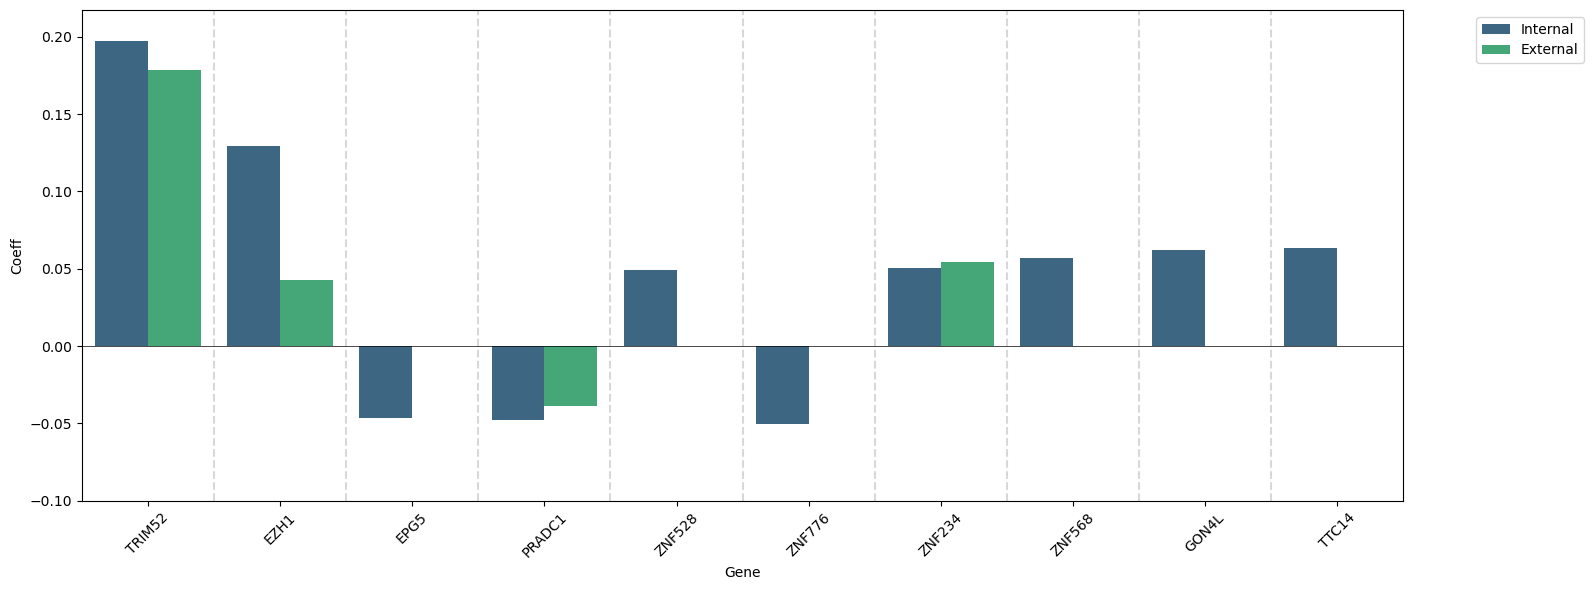

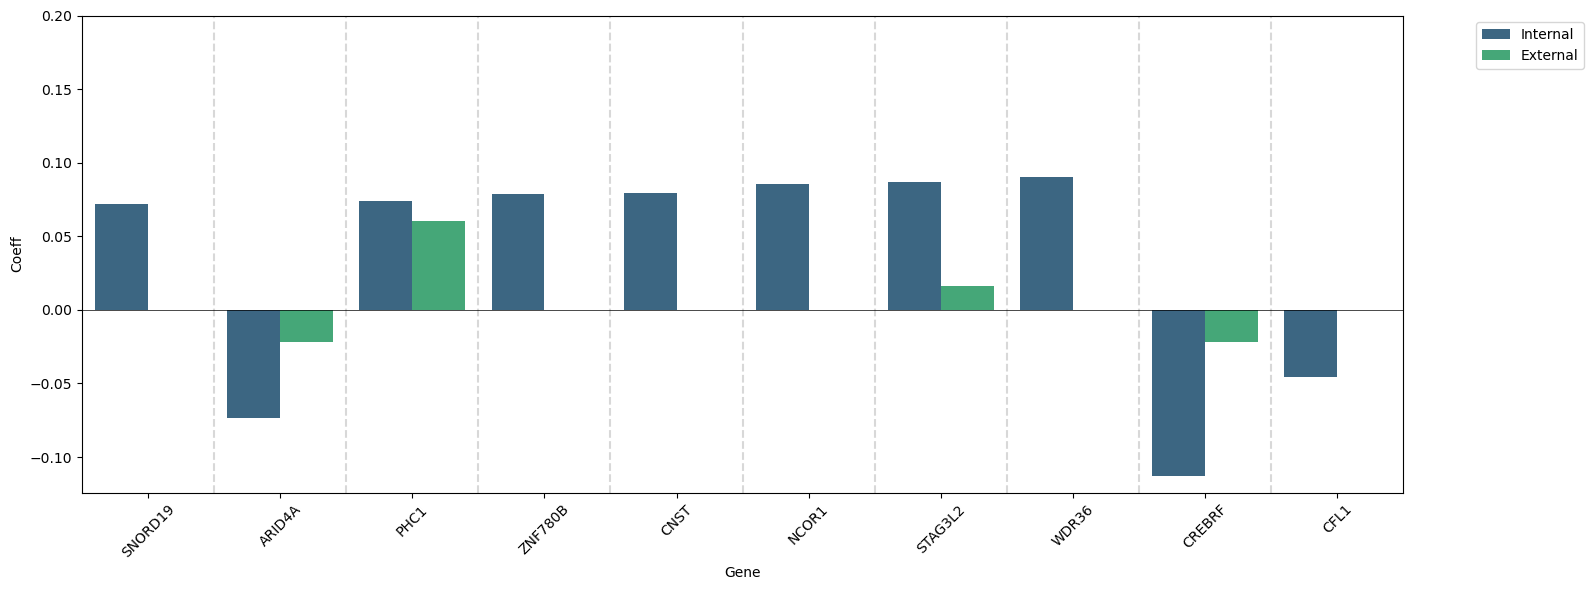

In [13]:
genes_per_plot = 10  
n_plots = (len(all_genes) + genes_per_plot - 1) // genes_per_plot

all_sources = df['Source'].unique()
output_dir = os.path.join('.', 'output', 'Y-zCoeff')
os.makedirs(output_dir, exist_ok=True)
for i in range(n_plots):
    start_idx = i * genes_per_plot
    end_idx = (i + 1) * genes_per_plot
    genes_subset = gene_order[start_idx:end_idx]
    
    df_subset = df_sorted[df_sorted['Index'].isin(genes_subset)]
    
    full_index = pd.MultiIndex.from_product(
        [genes_subset, all_sources],
        names=['Index', 'Source']
    )
    df_subset = df_subset.set_index(['Index', 'Source']).reindex(full_index).reset_index()
    
    plt.figure(figsize=(16, 6))
    ax = sns.barplot(x="Index",y="Value",hue="Source",data=df_subset,palette="viridis",dodge=True,order=genes_subset)
    
    for j in range(len(genes_subset)-1):
        ax.axvline(j+0.5, color='gray', linestyle='--', alpha=0.3)
    
    plt.xticks(rotation=45)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, all_sources, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    y_min = min(-0.1, df_subset['Value'].min() * 1.1)
    y_max = max(0.2, df_subset['Value'].max() * 1.1)
    plt.ylim(y_min, y_max)
    plt.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel("Gene")
    ax.set_ylabel("Coeff")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'Y-zCoeff{i}.pdf') , bbox_inches='tight', dpi=300)